# Clasificación de reseñas de hoteles con Word2Vec y LSTM

En esta tarea desarrollamos un clasificador de reseñas positivas y negativas en inglés. Usamos vectores Word2Vec preentrenados, una capa LSTM y una salida de clasificación binaria.

La entrada es el texto de la reseña (`text`) y la etiqueta es su polaridad (`polarity`): negativa = 0 y positiva = 1. La columna `deceptive` indica si la reseña es auténtica o fabricada y no se usa para entrenar.

### Preparación

La libreta se ejecuta en orden con Python 3.12. En el repositorio, el entorno se prepara con `uv sync` y Jupyter se abre con `uv run jupyter lab`, seleccionando el kernel de `.venv`.

Para ejecutar solo esta libreta, las dependencias se pueden instalar desde una terminal:

```bash
python -m pip install "tensorflow>=2.20,<2.21" "keras>=3.15,<3.16" "gensim>=4.4,<5" "numpy>=2.1,<2.3" "pandas>=2.2,<3" "scikit-learn>=1.6,<2" "matplotlib>=3.9,<4" "jupyterlab>=4.4,<5" "ipykernel>=6.29,<8"
python -m jupyter lab
```

La primera ejecución descarga el CSV y los embeddings si no están guardados. Word2Vec ocupa aproximadamente 1.74 GB comprimido y requiere varios GB de RAM al cargarlo. Los archivos se conservan en `data/` y los resultados en `artifacts/`. No es obligatorio contar con GPU.

### 0.1 · Importar librerías y preparar el entorno

Importamos las librerías, creamos las carpetas de trabajo y fijamos la semilla en 42. También mostramos las versiones y si TensorFlow detecta una GPU.

In [1]:
import os
from pathlib import Path
import sys, re, json, html, hashlib, gc
from collections import Counter
from importlib.metadata import version

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
EMBED_DIR = DATA_DIR / "embeddings"
ARTIFACT_DIR = ROOT / "artifacts"
for directory in (DATA_DIR, EMBED_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str(EMBED_DIR)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
import gensim.downloader as api
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from IPython.display import display, Markdown

SEED = 42
keras.utils.set_random_seed(SEED)
try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    print("TensorFlow ya estaba inicializado; se conserva su configuración de hilos.")
tf.config.experimental.enable_op_determinism()
VERSIONS = {name: version(name) for name in
            ["tensorflow", "keras", "gensim", "numpy", "pandas", "scikit-learn", "matplotlib"]}
print("Python:", sys.version.split()[0])
display(pd.Series(VERSIONS, name="versión").to_frame())
print("GPU:", tf.config.list_physical_devices("GPU"))


Python: 3.12.3


,versión
tensorflow,2.20.0
keras,3.15.1
gensim,4.4.0
numpy,2.2.6
pandas,2.3.3
scikit-learn,1.9.0
matplotlib,3.11.1


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Exploración de los datos

Revisamos las columnas del dataset, los valores faltantes, los textos repetidos y la cantidad de reseñas de cada clase.

### 1.1 · Leer el CSV

Cargamos el [CSV proporcionado en la tarea](https://raw.githubusercontent.com/AnIsAsPe/LogisticRegression_SpamOpinion/master/Datos/deceptive-opinion.csv). Si ya existe una copia local, la reutilizamos. Mostramos sus primeras filas y registramos la huella SHA256 del archivo.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/AnIsAsPe/LogisticRegression_SpamOpinion/master/Datos/deceptive-opinion.csv"
CSV_PATH = DATA_DIR / "deceptive-opinion.csv"
if not CSV_PATH.exists():
    pd.read_csv(DATA_URL).to_csv(CSV_PATH, index=False)
raw = pd.read_csv(CSV_PATH)
DATA_SHA256 = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
assert {"text", "polarity"}.issubset(raw.columns)
print("Forma:", raw.shape, "| SHA256:", DATA_SHA256)
display(raw.head(3))
raw.info()


Forma: (1600, 5) | SHA256: e98f9f9497fb9e056b7f5870b2fd551e706dcca8de3fd8269f9f1f0de71e3a77


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deceptive  1600 non-null   object
 1   hotel      1600 non-null   object
 2   polarity   1600 non-null   object
 3   source     1600 non-null   object
 4   text       1600 non-null   object
dtypes: object(5)
memory usage: 62.6+ KB


### 1.2 · Revisar calidad y clases

Contamos los valores nulos, los textos duplicados y las reseñas positivas y negativas. También revisamos cómo se distribuyen las clases entre reseñas auténticas y fabricadas.

,nulos
deceptive,0
hotel,0
polarity,0
source,0
text,0


,reseñas
polarity,
positive,800
negative,800


Textos repetidos: 4


polarity,negative,positive
deceptive,,
deceptive,400,400
truthful,400,400


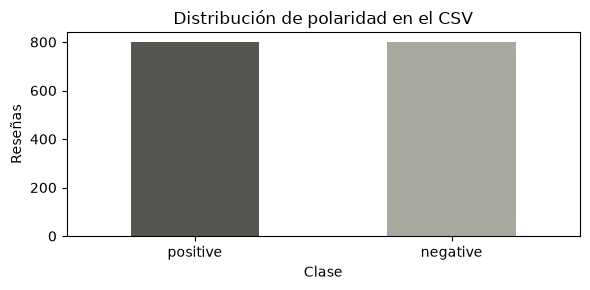

In [3]:
display(raw.isna().sum().rename("nulos").to_frame())
display(raw["polarity"].value_counts(dropna=False).rename("reseñas").to_frame())
print("Textos repetidos:", raw["text"].duplicated().sum())
display(pd.crosstab(raw["deceptive"], raw["polarity"]))
fig, ax = plt.subplots(figsize=(6, 3))
raw["polarity"].value_counts().plot.bar(ax=ax, color=["#555650", "#aaa99f"])
ax.set(title="Distribución de polaridad en el CSV", xlabel="Clase", ylabel="Reseñas")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 2. Preprocesamiento de textos

Limpiamos las reseñas antes de dividir los datos. Conservamos el orden de las palabras y las negaciones, porque son importantes para identificar el sentimiento.

### 2.1 · Limpiar registros y resolver duplicados

Quitamos registros sin texto o etiqueta y eliminamos duplicados, ignorando diferencias de espacios y mayúsculas. Comprobamos que un mismo texto no tenga etiquetas contradictorias.

In [4]:
df = raw.dropna(subset=["text", "polarity"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].ne("")].copy()
LABEL_MAP = {"negative": 0, "positive": 1}
unexpected = set(df["polarity"]) - set(LABEL_MAP)
assert not unexpected, f"Etiquetas no previstas: {unexpected}"
df["duplicate_key"] = df["text"].str.replace(r"\s+", " ", regex=True).str.casefold()
conflicts = df.groupby("duplicate_key")["polarity"].nunique()
assert not (conflicts > 1).any(), "Revisar textos con polaridad contradictoria."
df = df.drop_duplicates("duplicate_key").reset_index(drop=True)
df["label"] = df["polarity"].map(LABEL_MAP).astype("int32")
print(f"Registros originales: {len(raw)}; válidos únicos: {len(df)}")


Registros originales: 1600; válidos únicos: 1596


### 2.2 · Tokenizar conservando negaciones

Quitamos etiquetas HTML, normalizamos apóstrofos y separamos el texto en palabras. Expandimos negaciones como `wasn't` a `was not`. No eliminamos palabras frecuentes ni reducimos las palabras a su raíz.

Conservamos las mayúsculas porque Google News las distingue. Al buscar un vector, intentaremos primero la palabra original y después su versión en minúsculas.

In [5]:
TOKEN_PATTERN = r"[A-Za-z]+(?:'[A-Za-z]+)?"
def tokenize(text):
    text = html.unescape(str(text)).replace("’", "'")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.I)
    text = re.sub(r"\bcan't\b", "can not", text, flags=re.I)
    text = re.sub(r"\bshan't\b", "shall not", text, flags=re.I)
    text = re.sub(r"n't\b", " not", text, flags=re.I)
    return re.findall(TOKEN_PATTERN, text)

df["tokens"] = df["text"].map(tokenize)
empty_count = df["tokens"].map(len).eq(0).sum()
df = df[df["tokens"].map(len).gt(0)].copy()
# Evitar que entradas idénticas después de tokenizar crucen las particiones.
df["token_key"] = df["tokens"].map(lambda tokens: " ".join(tokens).casefold())
assert not (df.groupby("token_key")["label"].nunique() > 1).any(), "Revisar conflicto tras tokenizar."
df = df.drop_duplicates("token_key").reset_index(drop=True)
print("Textos sin tokens descartados:", empty_count)
display(df[["text", "tokens", "label"]].head(3))
assert "not" in tokenize("The room wasn't clean.")


Textos sin tokens descartados: 0


,text,tokens,label
0,We stayed for a one night getaway with family ...,"[We, stayed, for, a, one, night, getaway, with...",1
1,Triple A rate with upgrade to view room was le...,"[Triple, A, rate, with, upgrade, to, view, roo...",1
2,This comes a little late as I'm finally catchi...,"[This, comes, a, little, late, as, I'm, finall...",1


### 2.3 · Separar entrenamiento, validación y prueba

Dividimos las reseñas en aproximadamente 70% para entrenamiento, 15% para validación y 15% para prueba, manteniendo la proporción de clases.

Entrenamiento sirve para aprender los pesos; validación, para elegir cuándo detener el entrenamiento; y prueba, para medir el resultado final. El vocabulario y la longitud máxima se calculan solo con entrenamiento.

In [6]:
train_df, holdout_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(
    holdout_df, test_size=0.50, stratify=holdout_df["label"], random_state=SEED)
splits = {"entrenamiento": train_df, "validación": val_df, "prueba": test_df}
for a, b in [(train_df, val_df), (train_df, test_df), (val_df, test_df)]:
    assert set(a["token_key"]).isdisjoint(b["token_key"])
display(pd.DataFrame({
    name: part["label"].value_counts().reindex([0, 1], fill_value=0)
    for name, part in splits.items()
}).rename(index={0: "negativa", 1: "positiva"}))


,entrenamiento,validación,prueba
label,,,
negativa,557,119,120
positiva,560,120,120


## 3. Vectorización de texto: secuencias de entrada

Convertimos cada reseña en una secuencia de índices numéricos. Estos índices identifican palabras; la capa Embedding los usará para buscar sus vectores.

### 3.1 · Crear el vocabulario de entrenamiento

Asignamos un índice a cada palabra de entrenamiento, ordenando por frecuencia. Reservamos el 0 para relleno y el 1 para palabras desconocidas. Después de este paso, el vocabulario queda fijo.

In [7]:
PAD_ID, UNK_ID = 0, 1
counts = Counter(token for tokens in train_df["tokens"] for token in tokens)
ordered_words = sorted(counts, key=lambda word: (-counts[word], word))
word_index = {word: i + 2 for i, word in enumerate(ordered_words)}
V = len(word_index) + 2
index_word = {PAD_ID: "<PAD>", UNK_ID: "<UNK>", **{i: w for w, i in word_index.items()}}
print("V (incluye especiales):", V)
display(pd.DataFrame([(w, word_index[w], counts[w]) for w in ordered_words[:12]],
                     columns=["palabra", "índice", "frecuencia en entrenamiento"]))


V (incluye especiales): 9351


,palabra,índice,frecuencia en entrenamiento
0,the,2,9057
1,and,3,5533
2,to,4,4725
3,a,5,4463
4,was,6,4255
5,I,7,4216
6,in,8,2783
7,of,9,2335
8,The,10,2230
9,for,11,1960


### 3.2 · Elegir la longitud máxima

Usamos el percentil 95 de las longitudes de entrenamiento. Así conservamos completas aproximadamente el 95% de esas reseñas y evitamos rellenar todas hasta la longitud de la más larga.

`MAX_LEN` indica cuántas palabras caben en cada secuencia; no es el tamaño del vocabulario ni la dimensión de los embeddings.

L = 323


,tokens
count,1117.000000
mean,151.106535
std,91.054891
min,25.000000
50%,130.000000
90%,264.600000
95%,322.000000
99%,456.840000
max,794.000000


Fracción de reseñas de entrenamiento recortadas: 0.050134288272157566


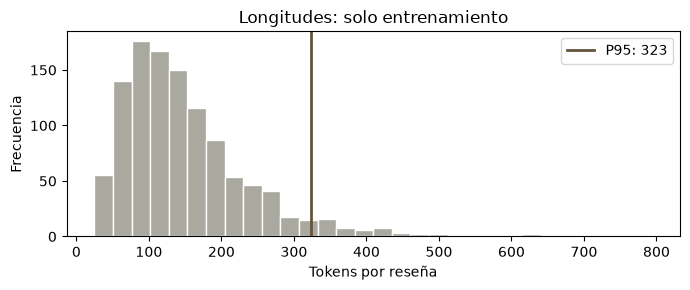

In [8]:
train_lengths = train_df["tokens"].map(len).to_numpy()
MAX_LEN = max(1, int(np.ceil(np.percentile(train_lengths, 95))))
PADDING, TRUNCATING = "pre", "post"
print("L =", MAX_LEN)
display(pd.Series(train_lengths).describe(percentiles=[.5, .9, .95, .99]).to_frame("tokens"))
print("Fracción de reseñas de entrenamiento recortadas:", np.mean(train_lengths > MAX_LEN))
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(train_lengths, bins=30, color="#aaa99f", edgecolor="white")
ax.axvline(MAX_LEN, color="#64543e", label=f"P95: {MAX_LEN}", linewidth=2)
ax.set(xlabel="Tokens por reseña", ylabel="Frecuencia", title="Longitudes: solo entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()


### 3.3 · Convertir a índices y aplicar pad_sequences

Convertimos las palabras a índices y usamos `pad_sequences(padding='pre')`, como pide la tarea. Las reseñas cortas reciben ceros al inicio; las largas se recortan al final. Las palabras desconocidas reciben el índice 1 y las etiquetas se guardan por separado.

In [9]:
def encode_tokens(tokens, vocabulary):
    return [vocabulary.get(token, UNK_ID) for token in tokens]

def vectorize(token_lists, vocabulary, max_len):
    sequences = [encode_tokens(tokens, vocabulary) for tokens in token_lists]
    return pad_sequences(sequences, maxlen=max_len, dtype="int32",
                         padding=PADDING, truncating=TRUNCATING, value=PAD_ID)

X_train = vectorize(train_df["tokens"], word_index, MAX_LEN)
X_val = vectorize(val_df["tokens"], word_index, MAX_LEN)
X_test = vectorize(test_df["tokens"], word_index, MAX_LEN)
y_train = train_df["label"].to_numpy(dtype="int32")
y_val = val_df["label"].to_numpy(dtype="int32")
y_test = test_df["label"].to_numpy(dtype="int32")
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    assert X.shape[1] == MAX_LEN and X.min() >= 0 and X.max() < V
    print(name, X.shape, "| desconocidas entre tokens:", (X == UNK_ID).sum() / (X != PAD_ID).sum())
example_tokens = tokenize("The hotel was clean")
print("Tokens:", example_tokens)
print("Índices:", encode_tokens(example_tokens, word_index))
print("Ejemplo con seis posiciones:", vectorize([example_tokens], word_index, 6)[0])


train (1117, 323) | desconocidas entre tokens: 0.0
val (239, 323) | desconocidas entre tokens: 0.02781081328332266
test (240, 323) | desconocidas entre tokens: 0.027518172377985463
Tokens: ['The', 'hotel', 'was', 'clean']
Índices: [10, 13, 6, 81]
Ejemplo con seis posiciones: [ 0  0 10 13  6 81]


## 4. Matriz de vectores Word2Vec preentrenados

Elegimos `word2vec-google-news-300` porque es un modelo Word2Vec reconocido, preentrenado en inglés, el idioma de las reseñas. Cada vector tiene 300 dimensiones.

El vocabulario de entrenamiento relaciona cada palabra con un índice. Buscamos su vector en Word2Vec y lo colocamos en la fila correspondiente de una nueva matriz. Gensim descarga el modelo completo, pero la red solo utiliza esta matriz con las palabras de nuestro vocabulario.

| Representación | Tamaño |
|---|---|
| Matriz de embeddings | V palabras × 300 dimensiones |
| Una reseña después de Embedding | L posiciones × 300 dimensiones |
| Un batch después de Embedding | B reseñas × L posiciones × 300 dimensiones |

Aprovechamos representaciones ya aprendidas y las mantenemos fijas. La LSTM y la capa de salida aprenderán a relacionarlas con las etiquetas de sentimiento.

Fuentes: [catálogo de Gensim](https://github.com/piskvorky/gensim-data/blob/master/list.json) y [descarga con Gensim](https://radimrehurek.com/gensim/downloader.html).

### 4.1 · Descargar y conservar los embeddings

Si el archivo no existe, lo descargamos con Gensim usando `return_path=True`, que lo guarda sin cargar todavía los vectores en RAM. Si ya está guardado, lo reutilizamos.

Verificamos su tamaño y MD5 para detectar una descarga incompleta o un archivo distinto al esperado.

In [10]:
W2V_NAME = "word2vec-google-news-300"
api.BASE_DIR = str(EMBED_DIR)
# Fuente: https://github.com/piskvorky/gensim-data/blob/master/list.json
model_info = {
    "num_records": 3_000_000,
    "file_size": 1_743_563_840,
    "base_dataset": "Google News (about 100 billion words)",
    "file_name": "word2vec-google-news-300.gz",
    "checksum": "a5e5354d40acb95f9ec66d5977d140ef",
    "parameters": {"dimension": 300},
}
D = model_info["parameters"]["dimension"]
w2v_path = EMBED_DIR / W2V_NAME / model_info["file_name"]
if w2v_path.is_file():
    print("Reutilizando archivo local; no se descarga:", w2v_path)
else:
    print("Descargando con Gensim, sin cargar vectores en RAM...")
    downloaded_path = Path(api.load(W2V_NAME, return_path=True))
    assert downloaded_path.resolve() == w2v_path.resolve()

actual_size = w2v_path.stat().st_size
if actual_size != model_info["file_size"]:
    raise ValueError(f"Archivo incompleto o distinto: {actual_size} bytes. Revisar {w2v_path}")
with w2v_path.open("rb") as stream:
    actual_md5 = hashlib.file_digest(stream, "md5").hexdigest()
if actual_md5 != model_info["checksum"]:
    raise ValueError(f"Checksum incorrecto. Revisar el archivo antes de cargarlo: {w2v_path}")

print("Tamaño y MD5 verificados. El archivo permanece en disco.")
display(pd.Series({k: model_info[k] for k in
                   ["num_records", "file_size", "base_dataset", "file_name"]}).to_frame("valor"))

Reutilizando archivo local; no se descarga: /home/maxkaizo/hotel_review/data/embeddings/word2vec-google-news-300/word2vec-google-news-300.gz
Tamaño y MD5 verificados. El archivo permanece en disco.


,valor
num_records,3000000
file_size,1743563840
base_dataset,Google News (about 100 billion words)
file_name,word2vec-google-news-300.gz


### 4.2 · Cargar los vectores

Leemos el archivo con `KeyedVectors.load_word2vec_format` en formato binario. Comprobamos que tenga 3 millones de entradas y vectores de 300 dimensiones. Este paso carga el modelo completo en RAM.

In [11]:
w2v = KeyedVectors.load_word2vec_format(str(w2v_path), binary=True)
assert w2v.vector_size == D
assert len(w2v.index_to_key) == model_info["num_records"]
print("Vocabulario preentrenado:", len(w2v.index_to_key))
print("Dimensión:", w2v.vector_size)
print("Vector de hotel:", w2v["hotel"][:8])

Vocabulario preentrenado: 3000000
Dimensión: 300
Vector de hotel: [ 0.02612305  0.0144043  -0.03442383 -0.00582886  0.02697754  0.05151367
 -0.12304688 -0.2890625 ]


### 4.3 · Construir la matriz de embeddings

Copiamos cada vector a la fila indicada por el índice de su palabra. Buscamos primero una coincidencia exacta y después en minúsculas.

Para las palabras sin vector y para `<UNK>`, usamos el promedio de los vectores encontrados. Es una solución sencilla, pero esas palabras compartirán la misma representación. La fila de relleno contiene ceros.

Calculamos qué proporción del vocabulario tiene vector y la cobertura ponderada por la frecuencia de las palabras.

In [12]:
embedding_matrix = np.zeros((V, D), dtype=np.float32)
matches = {}
missing_words = []
for word, idx in word_index.items():
    key = word if word in w2v else word.lower()
    if key in w2v:
        embedding_matrix[idx] = w2v[key]
        matches[word] = key
    else:
        missing_words.append(word)
assert matches, "Ninguna palabra coincide: revisar idioma o preprocesamiento."
matched_indices = [word_index[word] for word in matches]
fallback = embedding_matrix[matched_indices].mean(axis=0)
embedding_matrix[UNK_ID] = fallback
for word in missing_words:
    embedding_matrix[word_index[word]] = fallback
assert np.isfinite(embedding_matrix).all()
assert np.all(embedding_matrix[PAD_ID] == 0)
type_coverage = len(matches) / len(word_index)
token_coverage = sum(counts[w] for w in matches) / sum(counts.values())
print(f"Cobertura de palabras distintas: {type_coverage:.2%}")
print(f"Cobertura ponderada por frecuencia de entrenamiento: {token_coverage:.2%}")
print("Matriz:", embedding_matrix.shape, "| MB:", embedding_matrix.nbytes / 1e6)
print("Ejemplos ausentes:", missing_words[:20])
for word in ordered_words[:3]:
    idx = word_index[word]
    print(word, "→ fila", idx, "→", embedding_matrix[idx, :5])


Cobertura de palabras distintas: 95.74%
Cobertura ponderada por frecuencia de entrenamiento: 89.55%
Matriz: (9351, 300) | MB: 11.2212
Ejemplos ausentes: ['and', 'to', 'a', 'of', "hotel's", 'didnt', "Chicago's", "night's", "Shula's", 'centre', 'cancelled', 'theatre', 'wasnt', "room's", 'travelling', 'Kimptons', "TV's", 'bookit', 'consierge', "i'm"]
the → fila 2 → [ 0.08007812  0.10498047  0.04980469  0.0534668  -0.06738281]
and → fila 3 → [ 0.01789741  0.0446796  -0.00918847  0.07402582 -0.05544159]
to → fila 4 → [ 0.01789741  0.0446796  -0.00918847  0.07402582 -0.05544159]


### 4.4 · Guardar la matriz y liberar memoria

Guardamos la matriz, el vocabulario y la cobertura. Después liberamos el objeto Word2Vec completo de RAM. Conservamos la matriz necesaria para la red y el archivo descargado en disco para futuras ejecuciones.

In [13]:
np.save(ARTIFACT_DIR / "embedding_matrix.npy", embedding_matrix)
pd.DataFrame({
    "palabra": ordered_words,
    "indice": [word_index[w] for w in ordered_words],
    "clave_word2vec": [matches.get(w) for w in ordered_words],
    "frecuencia_train": [counts[w] for w in ordered_words],
}).to_csv(ARTIFACT_DIR / "cobertura_word2vec.csv", index=False)
(ARTIFACT_DIR / "embedding_vocabulary.json").write_text(
    json.dumps({"word_index": word_index, "pad_id": PAD_ID, "unk_id": UNK_ID,
                "source": W2V_NAME, "source_md5": actual_md5,
                "dimension": D}, ensure_ascii=False, indent=2),
    encoding="utf-8")
del w2v
gc.collect()
assert w2v_path.is_file()
print("Vectores completos liberados de RAM; archivo original conservado en:", w2v_path)
print("La matriz compacta y las reseñas siguen disponibles para continuar.")

Vectores completos liberados de RAM; archivo original conservado en: /home/maxkaizo/hotel_review/data/embeddings/word2vec-google-news-300/word2vec-google-news-300.gz
La matriz compacta y las reseñas siguen disponibles para continuar.


## 5. Diseño de la RNN

La red tiene las tres capas solicitadas:

- Embedding con los vectores Word2Vec y `trainable=False`.
- LSTM de 300 unidades, igual a la dimensión de los vectores, con `dropout=0.2`.
- Dense de una neurona con activación `sigmoid`.

Usamos `mask_zero=True` para ignorar el relleno. Como el padding previo con máscara no es compatible con la ruta cuDNN de la LSTM, configuramos `use_cudnn=False`. Esto no desactiva la GPU; TensorFlow asigna automáticamente los dispositivos.

Referencias: [LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) y [Embedding](https://keras.io/api/layers/core_layers/embedding/).

### 5.1 · Construir y compilar el modelo

Definimos el modelo secuencial. Elegimos sigmoid porque produce una probabilidad entre 0 y 1 para la clase positiva. Usamos pérdida `binary_crossentropy` y el optimizador Adam, que ajustará los pesos de la LSTM y de la salida.

In [14]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
model = keras.Sequential([
    keras.Input(shape=(MAX_LEN,), dtype="int32", name="indices"),
    keras.layers.Embedding(
        input_dim=V, output_dim=D,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix),
        trainable=False, mask_zero=True, name="word2vec_congelado"),
    keras.layers.LSTM(D, dropout=0.2, use_cudnn=False, name="lstm"),
    keras.layers.Dense(1, activation="sigmoid", name="polaridad"),
], name="hotel_word2vec_lstm")
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])
model.summary()
assert not model.get_layer("word2vec_congelado").trainable
assert model.get_layer("lstm").units == D
assert model.get_layer("lstm").dropout == 0.2


I0000 00:00:1788913639.674415  106646 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:07:00.0, compute capability: 8.6


Model: "hotel_word2vec_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_congelado (Embedding)  │ (None, 323, 300)       │     2,805,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 300)            │       721,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ polaridad (Dense)               │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,526,801 (13.45 MB)

 Trainable params: 721,501 (2.75 MB)

 Non-trainable params: 2,805,300 (10.70 MB)

### 5.2 · Comprobar el recorrido de una reseña

Verificamos las dimensiones: la reseña entra como L índices, pasa a L vectores de 300 números y termina en una probabilidad. También comprobamos que la máscara identifique los ceros de relleno. El modelo todavía no está entrenado.

In [15]:
one_review = X_train[:1]
embedded = model.get_layer("word2vec_congelado")(one_review)
mask = model.get_layer("word2vec_congelado").compute_mask(one_review)
print("Índices:", one_review.shape)
print("Vectores de una reseña:", embedded.shape)
print("Salida:", model(one_review, training=False).shape)
np.testing.assert_array_equal(mask.numpy(), one_review != PAD_ID)
np.testing.assert_allclose(embedded.numpy()[0], embedding_matrix[one_review[0]])


Índices: (1, 323)
Vectores de una reseña: (1, 323, 300)
Salida: (1, 1)


## 6. Entrenamiento y evaluación

Entrenamos con las reseñas de entrenamiento y usamos validación para seleccionar los mejores pesos. Después evaluamos el modelo con las reseñas de prueba.

### 6.1 · Preparar lotes y detención temprana

Usamos batches de 32 reseñas y un máximo de 12 épocas. Si la pérdida de validación no mejora durante 3 épocas, detenemos el entrenamiento y recuperamos los mejores pesos. El conjunto de prueba no participa en este proceso.

In [16]:
BATCH_SIZE = 32
MAX_EPOCHS = 12
THRESHOLD = 0.5
def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 2
    return ds.batch(BATCH_SIZE).with_options(options).prefetch(1)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.CSVLogger(str(ARTIFACT_DIR / "training_log.csv"), append=False),
]
embedding_before = model.get_layer("word2vec_congelado").get_weights()[0].copy()


### 6.2 · Entrenar el clasificador

Entrenamos y registramos la pérdida y la exactitud por época. También medimos el tiempo total de `model.fit`, incluida la validación, y lo guardamos en `training_timing.json`. Este tiempo no incluye la descarga ni el preprocesamiento.

Al terminar, verificamos que los embeddings no hayan cambiado e identificamos la época con menor pérdida de validación.

In [17]:
import time

training_started = time.perf_counter()
history = model.fit(train_ds, validation_data=val_ds,
                    epochs=MAX_EPOCHS, callbacks=callbacks, verbose=2)
training_seconds = time.perf_counter() - training_started
training_timing = {
    "total_fit_seconds": training_seconds,
    "epochs_completed": len(history.epoch),
    "batch_size": BATCH_SIZE,
    "scope": "model.fit, including initialization, validation and callbacks",
}
training_timing_path = ARTIFACT_DIR / "training_timing.json"
training_timing_path.write_text(
    json.dumps(training_timing, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Tiempo total de fit: {training_seconds:.2f} s ({training_seconds / 60:.2f} min)")
print("Registro de tiempo guardado en:", training_timing_path)
np.testing.assert_array_equal(
    embedding_before, model.get_layer("word2vec_congelado").get_weights()[0])
print("Verificado: los embeddings no cambiaron.")
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print("Época seleccionada por validación:", best_epoch)


Epoch 1/12


/home/maxkaizo/hotel_review/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


35/35 - 72s - 2s/step - accuracy: 0.6455 - loss: 0.6488 - val_accuracy: 0.6360 - val_loss: 0.6504
Epoch 2/12
35/35 - 68s - 2s/step - accuracy: 0.7126 - loss: 0.5848 - val_accuracy: 0.7448 - val_loss: 0.5559
Epoch 3/12
35/35 - 68s - 2s/step - accuracy: 0.8201 - loss: 0.4205 - val_accuracy: 0.8033 - val_loss: 0.4568
Epoch 4/12
35/35 - 69s - 2s/step - accuracy: 0.8747 - loss: 0.3191 - val_accuracy: 0.8870 - val_loss: 0.3470
Epoch 5/12
35/35 - 67s - 2s/step - accuracy: 0.8979 - loss: 0.2718 - val_accuracy: 0.8745 - val_loss: 0.3504
Epoch 6/12
35/35 - 67s - 2s/step - accuracy: 0.8854 - loss: 0.3060 - val_accuracy: 0.8996 - val_loss: 0.3106
Epoch 7/12
35/35 - 68s - 2s/step - accuracy: 0.8935 - loss: 0.2838 - val_accuracy: 0.8954 - val_loss: 0.3038
Epoch 8/12
35/35 - 67s - 2s/step - accuracy: 0.9176 - loss: 0.2352 - val_accuracy: 0.8619 - val_loss: 0.3630
Epoch 9/12
35/35 - 69s - 2s/step - accuracy: 0.9123 - loss: 0.2602 - val_accuracy: 0.8996 - val_loss: 0.3249
Epoch 10/12
35/35 - 68s - 2s/s

### 6.3 · Visualizar el aprendizaje

Graficamos la pérdida y la exactitud de entrenamiento y validación para revisar el aprendizaje y detectar sobreajuste. La línea vertical señala la época elegida.

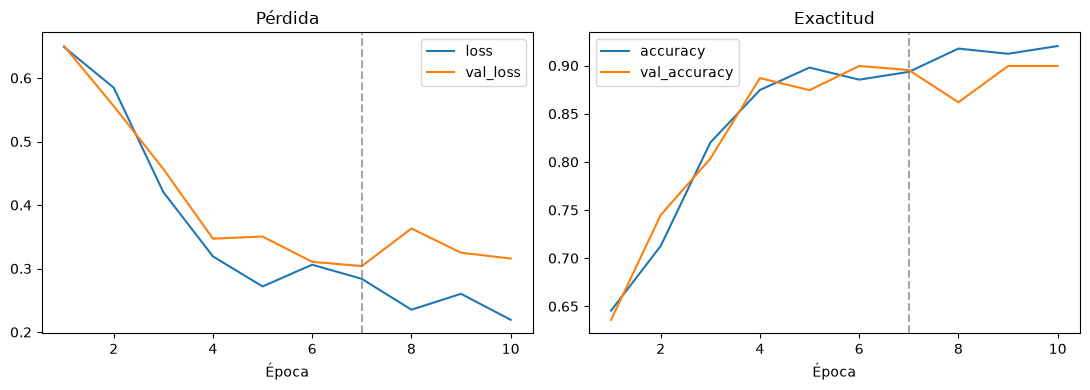

In [18]:
hist = pd.DataFrame(history.history)
hist.index = np.arange(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hist[["loss", "val_loss"]].plot(ax=axes[0], title="Pérdida")
hist[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Exactitud")
for ax in axes:
    ax.axvline(best_epoch, linestyle="--", color="gray", alpha=.7)
    ax.set_xlabel("Época")
plt.tight_layout()
plt.show()


### 6.4 · Evaluar con el conjunto de prueba

Clasificamos como positiva una reseña si su probabilidad es mayor o igual a 0.5. Calculamos accuracy, precisión, recall y F1, y mostramos la matriz de confusión.

Comparamos la LSTM con un clasificador que siempre predice la clase más frecuente de entrenamiento, como referencia básica.

,accuracy,precision_positive,recall_positive,f1_positive,f1_macro
LSTM,0.925,0.932203,0.916667,0.924370,0.924995
Mayoritaria,0.500,0.500000,1.000000,0.666667,0.333333


              precision    recall  f1-score   support

    negativa       0.92      0.93      0.93       120
    positiva       0.93      0.92      0.92       120

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.92       240
weighted avg       0.93      0.93      0.92       240



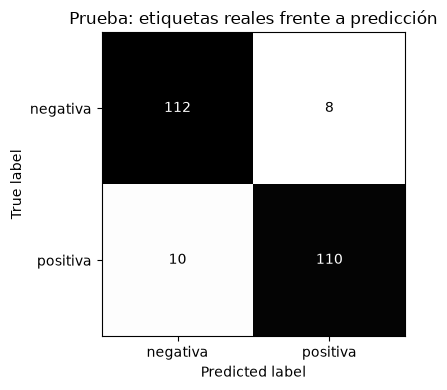

In [19]:
def predict_probabilities(classifier, X, batch_size=32):
    return np.concatenate([
        classifier(X[i:i + batch_size], training=False).numpy().ravel()
        for i in range(0, len(X), batch_size)
    ])

test_prob = predict_probabilities(model, X_test)
test_pred = (test_prob >= THRESHOLD).astype("int32")
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
base_pred = baseline.predict(np.zeros((len(y_test), 1)))

def score_predictions(y, prediction):
    return {"accuracy": accuracy_score(y, prediction),
            "precision_positive": precision_score(y, prediction, zero_division=0),
            "recall_positive": recall_score(y, prediction, zero_division=0),
            "f1_positive": f1_score(y, prediction, zero_division=0),
            "f1_macro": f1_score(y, prediction, average="macro", zero_division=0)}

metrics = pd.DataFrame({
    "LSTM": score_predictions(y_test, test_pred),
    "Mayoritaria": score_predictions(y_test, base_pred)
}).T
display(metrics)
print(classification_report(y_test, test_pred, labels=[0, 1],
                            target_names=["negativa", "positiva"], zero_division=0))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, labels=[0, 1],
    display_labels=["negativa", "positiva"], cmap="Greys", colorbar=False, ax=ax)
ax.set_title("Prueba: etiquetas reales frente a predicción")
plt.tight_layout()
plt.show()


### 6.5 · Revisar errores y guardar resultados

Mostramos algunos errores para observar qué reseñas resultaron difíciles. Guardamos las métricas y las predicciones, sin usar estos errores para reajustar el modelo.

In [20]:
results = test_df[["text", "hotel", "deceptive", "label"]].copy()
results["prob_positive"] = test_prob
results["prediction"] = test_pred
results["correct"] = results["label"] == results["prediction"]
results.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)
metrics.to_csv(ARTIFACT_DIR / "metrics.csv")
errors = results[~results["correct"]].copy()
print("Errores en prueba:", len(errors), "de", len(results))
display(errors[["text", "label", "prediction", "prob_positive"]].head(5))


Errores en prueba: 18 de 240


,text,label,prediction,prob_positive
814,Our trip was our annual anniversary trip. The ...,0,1,0.847803
72,We stayed at the Fairmont two nights for the S...,1,0,0.128741
1483,After staying at the James Chicago last weeken...,0,1,0.833888
45,I stayed at the Fairmont to attend a conferenc...,1,0,0.191838
195,"As others have said, once all the construction...",1,0,0.081739


### 6.6 · Guardar el modelo

Guardamos el modelo en formato `.keras`, junto con el vocabulario y las reglas de preprocesamiento. El archivo del modelo ya contiene los embeddings, por lo que no será necesario cargar Google News para clasificar nuevas reseñas.

In [21]:
MODEL_PATH = ARTIFACT_DIR / "hotel_lstm.keras"
CONFIG_PATH = ARTIFACT_DIR / "preprocessing.json"
model.save(MODEL_PATH)
config = {
    "word_index": word_index, "max_len": MAX_LEN, "padding": PADDING,
    "truncating": TRUNCATING, "pad_id": PAD_ID, "unk_id": UNK_ID,
    "threshold": THRESHOLD, "label_map": LABEL_MAP, "embedding_dim": D,
    "word2vec": W2V_NAME, "seed": SEED, "versions": VERSIONS,
    "data_sha256": DATA_SHA256, "token_pattern": TOKEN_PATTERN,
    "tokenizer_version": "html-apostrophes-negations-case-v1",
    "best_epoch": best_epoch,
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
split_manifest = pd.concat([
    part[["duplicate_key", "token_key"]].assign(split=name)
    for name, part in splits.items()
])
split_manifest.to_csv(ARTIFACT_DIR / "splits.csv", index=True)
print("Modelo y configuración guardados en:", ARTIFACT_DIR)


Modelo y configuración guardados en: /home/maxkaizo/hotel_review/artifacts


### 6.7 · Recargar y clasificar reseñas nuevas

Recargamos el modelo y verificamos que produzca las mismas probabilidades que el original usando las mismas entradas y el mismo tamaño de batch.

Para una reseña nueva, aplicamos la misma limpieza, buscamos los índices en el vocabulario y ajustamos la longitud con padding o truncamiento. El modelo devuelve la probabilidad de que sea positiva y asignamos la clase con el umbral de 0.5.

In [22]:
loaded_model = keras.models.load_model(MODEL_PATH)
saved = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
np.testing.assert_allclose(
    predict_probabilities(loaded_model, X_test[:3]),
    predict_probabilities(model, X_test[:3]),
    atol=1e-6,
    rtol=1e-5,
)

def classify_reviews(texts):
    if isinstance(texts, str):
        texts = [texts]
    if not texts:
        raise ValueError("Proporciona al menos una reseña.")
    token_lists = [tokenize(text) for text in texts]
    if any(not tokens for tokens in token_lists):
        raise ValueError("Cada reseña debe contener al menos una palabra.")
    sequences = [[saved["word_index"].get(t, saved["unk_id"]) for t in tokens]
                 for tokens in token_lists]
    X = pad_sequences(sequences, maxlen=saved["max_len"],
        padding=saved["padding"], truncating=saved["truncating"],
        value=saved["pad_id"], dtype="int32")
    probabilities = predict_probabilities(loaded_model, X)
    return pd.DataFrame({"reseña": texts, "prob_positiva": probabilities,
        "clasificación": np.where(probabilities >= saved["threshold"], "positiva", "negativa")})

display(classify_reviews([
    "The room was clean and the staff were very helpful. I would stay again.",
    "The room was dirty and noisy. The service was terrible.",
    "The hotel was not clean, although the location was convenient."
]))


,reseña,prob_positiva,clasificación
0,The room was clean and the staff were very hel...,0.681263,positiva
1,The room was dirty and noisy. The service was ...,0.277050,negativa
2,"The hotel was not clean, although the location...",0.451477,negativa


## 7. Conclusiones

Word2Vec nos permitió aprovechar vectores preentrenados sin modificarlos. La LSTM y la capa de salida aprendieron a clasificar las reseñas usando sus etiquetas.

El modelo tiene algunas limitaciones: las palabras sin vector comparten una representación, las reseñas largas pierden su parte final y Word2Vec asigna el mismo vector a una palabra aunque cambie el contexto.

Además, los datos mezclan reseñas auténticas y fabricadas, y un mismo hotel puede aparecer en entrenamiento y prueba. Los resultados describen este conjunto de datos; para evaluar hoteles nuevos habría que separarlos por hotel.

### 7.1 · Resumen de resultados

Reunimos el tamaño de los conjuntos, la cobertura de Word2Vec, la época seleccionada y las métricas de prueba. También mostramos la diferencia frente al clasificador de referencia y el número de errores.

In [24]:
delta = metrics.loc["LSTM", "accuracy"] - metrics.loc["Mayoritaria", "accuracy"]
relation = "superó" if delta > 0 else ("igualó" if delta == 0 else "quedó por debajo de")
summary = f"""
### Resultados de esta ejecución

- Se conservaron **{len(df)} reseñas** tras la limpieza: {len(train_df)} de entrenamiento,
  {len(val_df)} de validación y {len(test_df)} de prueba.
- El vocabulario tiene **{V:,} entradas** y la longitud máxima es **{MAX_LEN} tokens**.
  La matriz Word2Vec tiene forma **{V:,} × {D}**.
- La cobertura de palabras distintas de entrenamiento fue **{type_coverage:.1%}**;
  ponderada por frecuencia, **{token_coverage:.1%}**.
- Los embeddings permanecieron congelados. Validación seleccionó la época **{best_epoch}**.
- En prueba: accuracy **{metrics.loc['LSTM', 'accuracy']:.3f}**,
  F1 positivo **{metrics.loc['LSTM', 'f1_positive']:.3f}** y
  F1 macro **{metrics.loc['LSTM', 'f1_macro']:.3f}**.
- En accuracy, la LSTM **{relation}** la referencia mayoritaria;
  diferencia de **{delta * 100:+.2f} puntos porcentuales**.
- Hubo **{len(errors)} errores** sobre {len(results)} reseñas de prueba.
  Estos errores y las curvas deben interpretarse junto con las limitaciones descritas arriba.

El aprendizaje por transferencia aportó representaciones fijas; las etiquetas permitieron
entrenar el clasificador. La recarga del modelo conservó sus predicciones.
"""
display(Markdown(summary))
(ARTIFACT_DIR / "conclusiones.md").write_text(summary, encoding="utf-8")



### Resultados de esta ejecución

- Se conservaron **1596 reseñas** tras la limpieza: 1117 de entrenamiento,
  239 de validación y 240 de prueba.
- El vocabulario tiene **9,351 entradas** y la longitud máxima es **323 tokens**.
  La matriz Word2Vec tiene forma **9,351 × 300**.
- La cobertura de palabras distintas de entrenamiento fue **95.7%**;
  ponderada por frecuencia, **89.6%**.
- Los embeddings permanecieron congelados. Validación seleccionó la época **7**.
- En prueba: accuracy **0.925**,
  F1 positivo **0.924** y
  F1 macro **0.925**.
- En accuracy, la LSTM **superó** la referencia mayoritaria;
  diferencia de **+42.50 puntos porcentuales**.
- Hubo **18 errores** sobre 240 reseñas de prueba.
  Estos errores y las curvas deben interpretarse junto con las limitaciones descritas arriba.

El aprendizaje por transferencia aportó representaciones fijas; las etiquetas permitieron
entrenar el clasificador. La recarga del modelo conservó sus predicciones.


969